# Day 9 Capstone — Structural Health Monitoring of a Highway Bridge
### A civil-engineering case study in unsupervised learning

---
## Problem statement

The **Ravi Crossing**, a four-span steel-girder highway bridge, has been fitted with a permanent **Structural Health Monitoring (SHM)** system: twelve sensors — strain gauges, an LVDT, accelerometers, displacement transducers, an inclinometer and thermistors — log the structure around the clock. After a few months the asset team has **millions of readings and no labels**. Nobody has tagged which rows are 'normal' or 'damaged'; manually reviewing the stream is impossible.

The engineers need to answer three unsupervised questions:

1. **What are the bridge's normal operating regimes?** Behaviour is dominated by *temperature* (thermal expansion) and *traffic load*. Can we automatically discover the handful of states the bridge cycles through?
2. **Can we compress the 12 coupled sensors** into a few meaningful indices an engineer can monitor?
3. **Which readings are anomalous?** A developing crack or bearing seizure shifts the structure's response (a drop in modal frequency, strain redistribution). We need to **flag the unusual readings for inspection** — without ever having been shown an example of damage.

This is a textbook **unsupervised** problem: no target variable, just structure to be discovered. You'll apply the full Day 9 toolkit — scaling, **PCA**, **k-means**, the **elbow & silhouette** methods, **hierarchical clustering**, **Gaussian mixtures**, and **anomaly detection** — to turn a raw sensor feed into an actionable monitoring scheme.

## The data

`shm_bridge_monitoring.csv` — one row per logging interval, 12 sensor channels. `shm_sensor_registry.xlsx` — the sensor inventory (id, type, location, unit, range). Two extra columns `regime` and `event` are included **only so we can validate** our unsupervised results; a live feed would not have them, so we set them aside until evaluation.

_Phase E · Day 9 · Unsupervised Learning._

#objectives

Scale heterogeneous sensor data and read its correlation structure

Use PCA to compress 12 coupled channels into a few health indices

Discover operating regimes with k-means, validated by elbow & silhouette

Confirm structure with hierarchical clustering and soft GMM assignment

Detect anomalies (potential damage) and recommend an inspection workflow

#skill map — Day 9 → this study

| Stage | Day 9 skill |
| ----- | ----------- |
| 1 Explore & scale | distance/scale sensitivity, standardisation |
| 2 Compress | PCA, variance explained |
| 3 Choose k | elbow (inertia), silhouette |
| 4 Cluster | k-means, cluster profiling |
| 5 Confirm | hierarchical clustering, dendrogram |
| 6 Soft model | Gaussian Mixture, BIC |
| 7 Detect | anomaly / novelty detection |
| 8 Act | interpretation & monitoring recommendations |

In [1]:
# === SETUP: load the provided resources (regenerate them if missing) ===
import os
import numpy as np
import pandas as pd


def build_shm(csv_path="shm_bridge_monitoring.csv", xlsx_path="shm_sensor_registry.xlsx",
              seed=909, verbose=False):
    """Structural Health Monitoring stream from a highway girder bridge (UNLABELLED).

    A 12-sensor array logs the bridge at regular intervals. Readings are governed by two
    operational drivers — ambient TEMPERATURE (thermal expansion) and TRAFFIC load — which
    create a handful of natural operating REGIMES (season x time-of-day). Most sensors are
    physically coupled (strain gauges, deflection, bearing displacement all move with temp &
    load), so the data is highly correlated -> good for PCA. A small fraction of readings are
    ANOMALIES: a developing-damage signature (modal-frequency drop + strain redistribution) or
    raw sensor glitches -> what anomaly detection must surface.

    Hidden columns `regime` and `event` are included ONLY so the lab can validate clustering
    (ARI) and anomaly detection (precision/recall); a real feed would not have them.
    """
    rng = np.random.default_rng(seed)
    REF = 20.0  # reference temperature (deg C)

    # latent operating regimes: (label, mean air temp, mean traffic count, n)
    regimes = [
        ("winter_offpeak", 5.0,  90,  760),
        ("winter_peak",    8.0,  520, 640),
        ("summer_offpeak", 28.0, 120, 780),
        ("summer_peak",    33.0, 610, 670),
    ]
    rows, reg_lab = [], []
    for name, tmu, qmu, n in regimes:
        air = rng.normal(tmu, 2.2, n)
        traffic = np.clip(rng.normal(qmu, 60, n), 0, None)
        rows.append((air, traffic)); reg_lab += [name] * n

    air = np.concatenate([r[0] for r in rows])
    traffic = np.concatenate([r[1] for r in rows])
    regime = np.array(reg_lab)
    N = air.size

    deck = air + rng.normal(3.0, 1.4, N)            # deck warmer than air (solar)
    humidity = np.clip(70 - 0.6 * air + rng.normal(0, 5, N), 15, 100)
    thermal = deck - REF                            # thermal driver
    load = traffic                                  # load driver

    deflection = 4.0 + 0.010 * load + 0.18 * thermal + rng.normal(0, 0.35, N)
    strain1 = 60 + 0.070 * load + 1.60 * thermal + rng.normal(0, 5.0, N)
    strain2 = 55 + 0.065 * load + 1.50 * thermal + rng.normal(0, 5.0, N)
    strain3 = 50 + 0.060 * load + 1.40 * thermal + rng.normal(0, 5.0, N)
    nat_freq = 2.60 - 0.004 * thermal - 2e-5 * load + rng.normal(0, 0.015, N)
    accel = np.clip(2.0 + 0.020 * load + rng.normal(0, 1.3, N), 0, None)
    bearing = 5.0 + 0.45 * thermal + rng.normal(0, 0.7, N)
    tilt = 0.30 * thermal + 0.002 * load + rng.normal(0, 3.0, N)

    df = pd.DataFrame({
        "air_temp_c": air, "deck_temp_c": deck, "humidity_pct": humidity,
        "traffic_count": traffic, "mid_deflection_mm": deflection,
        "strain_g1_ue": strain1, "strain_g2_ue": strain2, "strain_g3_ue": strain3,
        "natural_freq_hz": nat_freq, "accel_rms_mg": accel,
        "bearing_disp_mm": bearing, "pier_tilt_urad": tilt,
        "regime": regime, "event": 0,
    })

    # ---- inject anomalies -------------------------------------------------
    n_evt = 75
    idx = rng.choice(N, n_evt, replace=False)
    n_damage = int(n_evt * 0.7)
    dmg, glitch = idx[:n_damage], idx[n_damage:]
    # (A) developing damage: stiffness loss -> frequency drop + strain redistribution + more sag
    df.loc[dmg, "natural_freq_hz"] -= rng.uniform(0.10, 0.20, len(dmg))
    df.loc[dmg, "strain_g1_ue"] += rng.uniform(25, 55, len(dmg))
    df.loc[dmg, "strain_g3_ue"] -= rng.uniform(15, 35, len(dmg))
    df.loc[dmg, "mid_deflection_mm"] += rng.uniform(1.2, 2.6, len(dmg))
    # (B) sensor glitches: one channel rails / drops out
    for i in glitch:
        ch = rng.choice(["strain_g2_ue", "accel_rms_mg", "bearing_disp_mm", "pier_tilt_urad"])
        df.loc[i, ch] = df[ch].mean() + rng.choice([-1, 1]) * rng.uniform(6, 10) * df[ch].std()
    df.loc[idx, "event"] = 1

    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    num = df.select_dtypes("number").columns
    df[num] = df[num].round(3)
    df.to_csv(csv_path, index=False)

    # ---- sensor registry (Excel) -----------------------------------------
    reg = pd.DataFrame([
        ["S01", "air_temp_c",        "Thermistor",      "Soffit, mid-span",   "deg C",      "-20..50"],
        ["S02", "deck_temp_c",       "Thermistor",      "Deck surface",       "deg C",      "-20..60"],
        ["S03", "humidity_pct",      "Hygrometer",      "Abutment",           "%RH",        "0..100"],
        ["S04", "traffic_count",     "WIM loop",        "Approach lane",      "veh/interval","0..1200"],
        ["S05", "mid_deflection_mm", "LVDT",            "Mid-span",           "mm",         "0..30"],
        ["S06", "strain_g1_ue",      "Strain gauge",    "Girder 1 soffit",    "microstrain","0..400"],
        ["S07", "strain_g2_ue",      "Strain gauge",    "Girder 2 soffit",    "microstrain","0..400"],
        ["S08", "strain_g3_ue",      "Strain gauge",    "Girder 3 soffit",    "microstrain","0..400"],
        ["S09", "natural_freq_hz",   "Accelerometer",   "Mid-span (modal)",   "Hz",         "1.5..3.5"],
        ["S10", "accel_rms_mg",      "Accelerometer",   "Mid-span (vert.)",   "mg",         "0..50"],
        ["S11", "bearing_disp_mm",   "Displacement xdcr","Expansion bearing", "mm",         "-40..40"],
        ["S12", "pier_tilt_urad",    "Inclinometer",    "Pier 2 cap",         "microrad",   "-200..200"],
    ], columns=["sensor_id", "channel", "sensor_type", "location", "unit", "nominal_range"])
    reg.to_excel(xlsx_path, index=False, sheet_name="sensors")

    if verbose:
        print("SHM:", df.shape, "| anomaly rate:", round(df.event.mean(), 3))
        print("regime sizes:\n", df.regime.value_counts().to_string())
        print("feature scale spread (max-min):")
        print(df[num].drop(columns=["event"]).agg(lambda c: c.max() - c.min()).round(1).to_string())
    return df

if not (os.path.exists('shm_bridge_monitoring.csv') and os.path.exists('shm_sensor_registry.xlsx')):
    build_shm(); print('Generated dataset + registry.')
else:
    print('Found the provided resources.')

Found the provided resources.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('shm_bridge_monitoring.csv')
registry = pd.read_excel('shm_sensor_registry.xlsx')
# the 12 sensor channels (set aside the validation-only columns)
channels = [c for c in df.select_dtypes('number').columns if c != 'event']
print('readings:', df.shape[0], '| channels:', len(channels))
display(registry)
df[channels].head(3)

readings: 2850 | channels: 12


,sensor_id,channel,sensor_type,location,unit,nominal_range
0,S01,air_temp_c,Thermistor,"Soffit, mid-span",deg C,-20..50
1,S02,deck_temp_c,Thermistor,Deck surface,deg C,-20..60
2,S03,humidity_pct,Hygrometer,Abutment,%RH,0..100
3,S04,traffic_count,WIM loop,Approach lane,veh/interval,0..1200
4,S05,mid_deflection_mm,LVDT,Mid-span,mm,0..30
5,S06,strain_g1_ue,Strain gauge,Girder 1 soffit,microstrain,0..400
6,S07,strain_g2_ue,Strain gauge,Girder 2 soffit,microstrain,0..400
7,S08,strain_g3_ue,Strain gauge,Girder 3 soffit,microstrain,0..400
8,S09,natural_freq_hz,Accelerometer,Mid-span (modal),Hz,1.5..3.5
9,S10,accel_rms_mg,Accelerometer,Mid-span (vert.),mg,0..50


,air_temp_c,deck_temp_c,humidity_pct,traffic_count,mid_deflection_mm,strain_g1_ue,strain_g2_ue,strain_g3_ue,natural_freq_hz,accel_rms_mg,bearing_disp_mm,pier_tilt_urad
0,9.519,17.052,67.388,521.305,8.155,89.712,80.227,83.099,2.611,12.273,2.176,-2.718
1,30.376,33.054,56.242,550.264,11.569,118.280,100.941,101.628,2.559,11.320,11.339,10.942
2,4.896,5.907,69.545,143.516,3.479,54.157,42.434,38.538,2.641,3.427,-0.200,-7.966


## Stage 1 — Explore & scale
Sensors live on wildly different numeric scales (microstrain in the hundreds, frequency near 2.6 Hz). Any distance-based method would be dominated by the large-magnitude channels, so we **standardise**.

In [3]:
# Scale spread shows why standardisation is mandatory
spread = (df[channels].max() - df[channels].min()).sort_values(ascending=False)
print('range (max - min) per channel:')
print(spread.round(1).to_string())

range (max - min) per channel:
traffic_count        757.6
strain_g2_ue         498.3
strain_g1_ue         171.0
strain_g3_ue         118.5
accel_rms_mg          91.0
pier_tilt_urad        60.0
bearing_disp_mm       59.7
humidity_pct          46.9
deck_temp_c           43.9
air_temp_c            42.2
mid_deflection_mm     15.6
natural_freq_hz        0.4


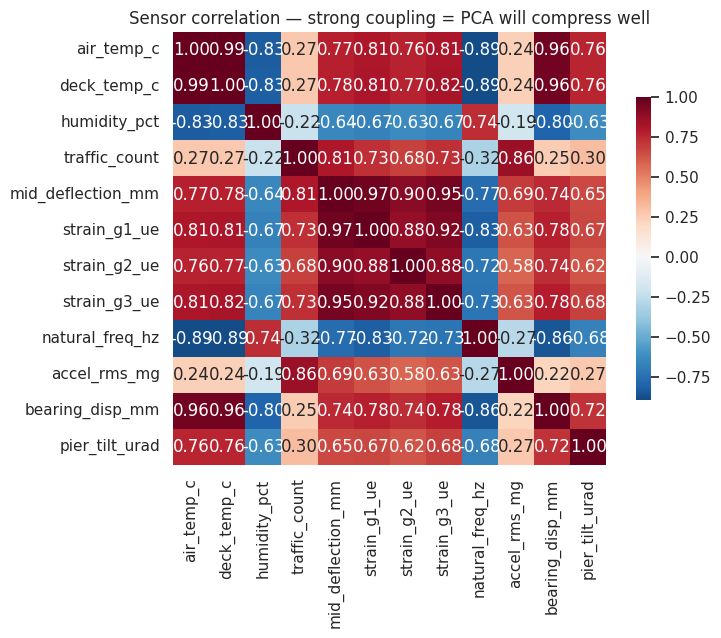

In [4]:
# Correlation structure: strain gauges, deflection, bearing & tilt move together (temp + load)
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(df[channels].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': .7}, ax=ax)
ax.set_title('Sensor correlation — strong coupling = PCA will compress well')
plt.tight_layout(); plt.show()

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(df[channels])
print('standardised matrix:', X.shape, '| each channel now mean 0, sd 1')

standardised matrix: (2850, 12) | each channel now mean 0, sd 1


## Stage 2 — Compress with PCA
Twelve coupled sensors carry far fewer than twelve independent stories. PCA finds the dominant modes of variation — here, essentially a *thermal+load* common mode plus a couple of finer axes.

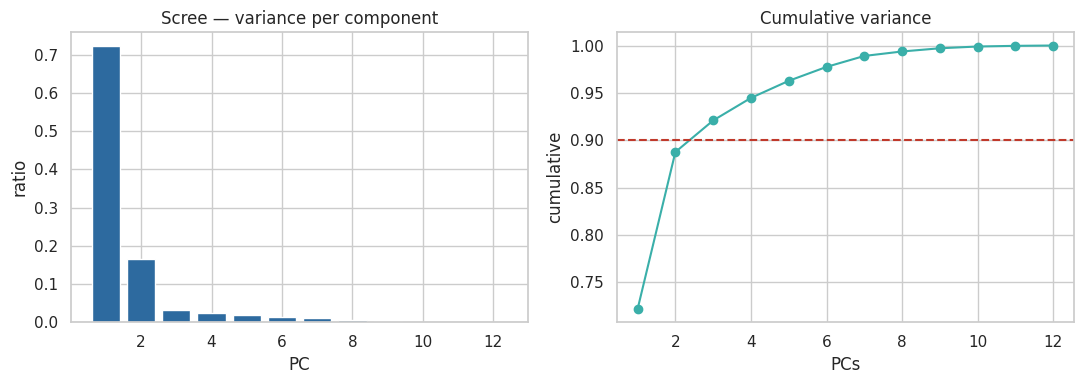

3 principal components capture >=90% of the variance (from 12 sensors).


In [6]:
from sklearn.decomposition import PCA
pca = PCA().fit(X)
cum = np.cumsum(pca.explained_variance_ratio_)
n90 = int(np.argmax(cum >= 0.90) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(range(1, len(cum) + 1), pca.explained_variance_ratio_, color='#2D6A9F')
ax[0].set_title('Scree — variance per component'); ax[0].set_xlabel('PC'); ax[0].set_ylabel('ratio')
ax[1].plot(range(1, len(cum) + 1), cum, 'o-', color='#3AAFA9'); ax[1].axhline(0.9, ls='--', color='#C0392B')
ax[1].set_title('Cumulative variance'); ax[1].set_xlabel('PCs'); ax[1].set_ylabel('cumulative')
plt.tight_layout(); plt.show()
print(f'{n90} principal components capture >=90% of the variance (from 12 sensors).')

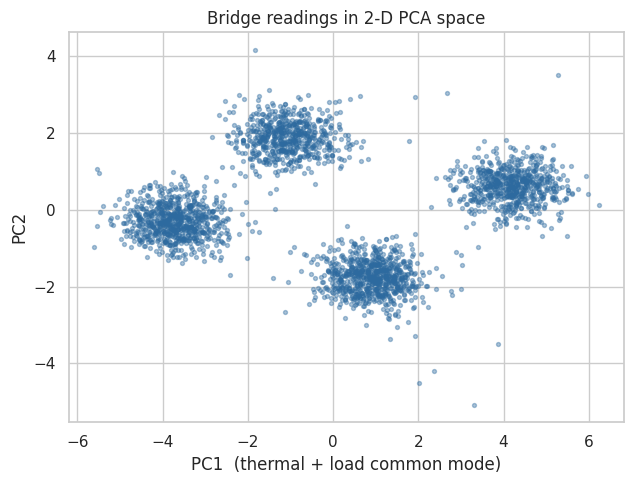

Distinct blobs already hint at a few operating regimes.


In [7]:
# Project to 2-D for visual intuition (we keep the first few PCs for downstream work)
P = PCA(n_components=2, random_state=0).fit_transform(X)
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(P[:, 0], P[:, 1], s=8, alpha=0.4, color='#2D6A9F')
ax.set_xlabel('PC1  (thermal + load common mode)'); ax.set_ylabel('PC2')
ax.set_title('Bridge readings in 2-D PCA space'); plt.tight_layout(); plt.show()
print('Distinct blobs already hint at a few operating regimes.')

## Stage 3 — How many regimes? Elbow & silhouette
We have no labels, so we let two internal criteria vote on the number of clusters `k`.

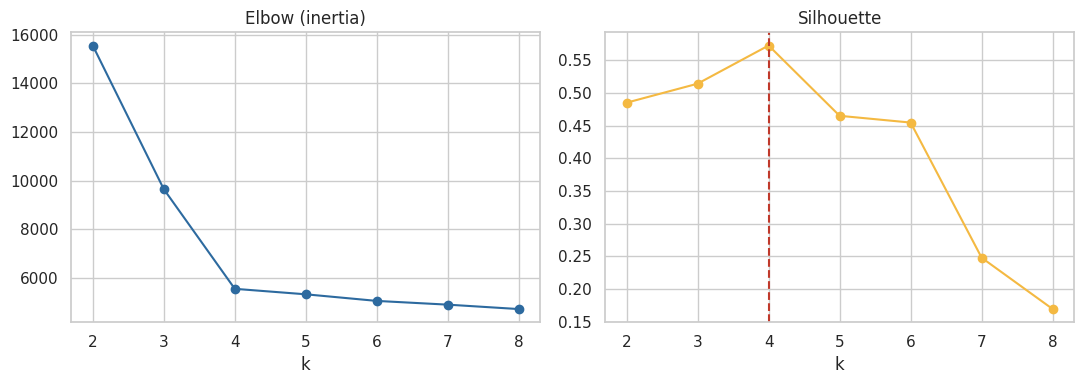

best k by silhouette: 4


In [8]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
ks = range(2, 9); inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    inertia.append(km.inertia_); sil.append(silhouette_score(X, km.labels_))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(ks), inertia, 'o-', color='#2D6A9F'); ax[0].set_title('Elbow (inertia)'); ax[0].set_xlabel('k')
ax[1].plot(list(ks), sil, 'o-', color='#F4B942'); ax[1].set_title('Silhouette'); ax[1].set_xlabel('k')
best_k = list(ks)[int(np.argmax(sil))]
ax[1].axvline(best_k, ls='--', color='#C0392B')
plt.tight_layout(); plt.show()
print('best k by silhouette:', best_k)

## Stage 4 — Discover & profile the operating regimes
With `k` chosen, k-means partitions the readings. We then **profile** each cluster on the raw sensors to give it an engineering name.

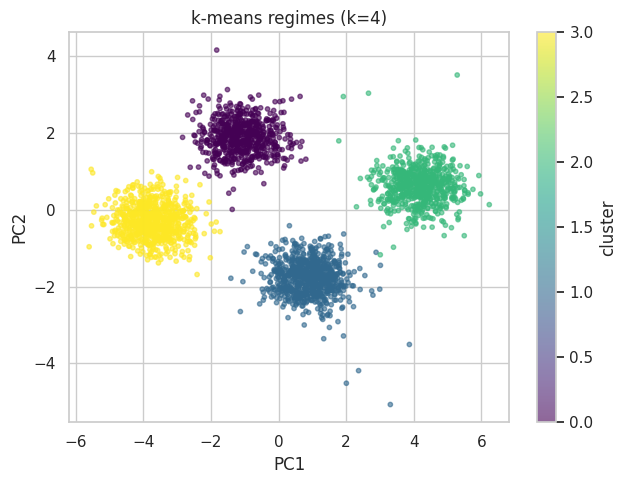

In [9]:
km = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit(X)
df['cluster'] = km.labels_
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(P[:, 0], P[:, 1], c=km.labels_, cmap='viridis', s=10, alpha=0.6)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title(f'k-means regimes (k={best_k})')
plt.colorbar(sc, label='cluster'); plt.tight_layout(); plt.show()

In [10]:
# Profile clusters on interpretable channels
profile = df.groupby('cluster')[['air_temp_c', 'traffic_count', 'mid_deflection_mm',
                                  'strain_g1_ue', 'bearing_disp_mm', 'natural_freq_hz']].mean().round(1)
profile['n'] = df.groupby('cluster').size()
print(profile.to_string())
print('\nRead the temperature and traffic columns to name each regime',
      '(e.g. cold+low-traffic = winter off-peak, warm+high-traffic = summer peak).')

         air_temp_c  traffic_count  mid_deflection_mm  strain_g1_ue  bearing_disp_mm  natural_freq_hz    n
cluster                                                                                                   
0               8.1          520.8                7.6          82.9              1.0              2.6  640
1              28.0          123.4                7.2          87.2             10.1              2.5  781
2              32.9          604.5               13.0         128.6             12.2              2.5  671
3               5.1           95.4                2.8          48.3             -0.4              2.6  758

Read the temperature and traffic columns to name each regime (e.g. cold+low-traffic = winter off-peak, warm+high-traffic = summer peak).


In [11]:
# Validate against the hidden regime label (we would NOT have this in production)
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(df['regime'], df['cluster'])
print('Adjusted Rand Index vs the true operating regimes:', round(ari, 3))
print('(1.0 = perfect recovery; our unsupervised clusters match the real regimes very closely.)')

Adjusted Rand Index vs the true operating regimes: 0.986
(1.0 = perfect recovery; our unsupervised clusters match the real regimes very closely.)


## Stage 5 — Confirm the structure with hierarchical clustering
A dendrogram is a second opinion: if the data really splits into a few regimes, the tree shows tall merges at that level.

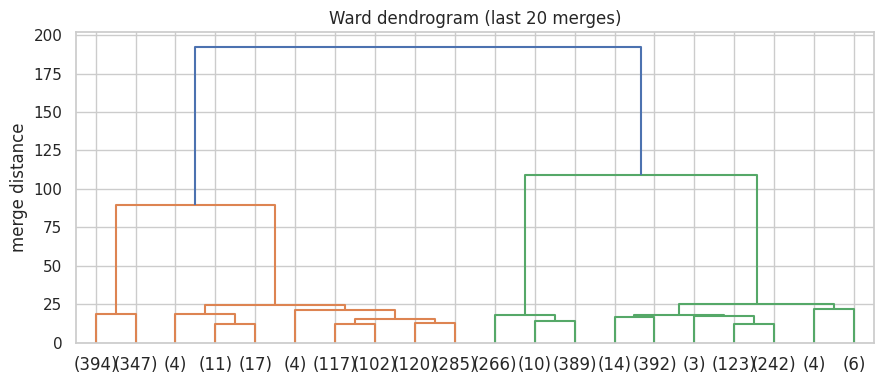

hierarchical vs k-means agreement (ARI): 0.972


In [12]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
Z = linkage(X, method='ward')
fig, ax = plt.subplots(figsize=(9, 4))
dendrogram(Z, truncate_mode='lastp', p=20, ax=ax, color_threshold=0.6 * max(Z[:, 2]))
ax.set_title('Ward dendrogram (last 20 merges)'); ax.set_ylabel('merge distance'); plt.tight_layout(); plt.show()
hier = fcluster(Z, t=best_k, criterion='maxclust')
print('hierarchical vs k-means agreement (ARI):', round(adjusted_rand_score(hier, km.labels_), 3))

## Stage 6 — Soft assignment with a Gaussian Mixture
Real bridge states blend into one another (dawn warming, traffic ramping up). A GMM gives each reading a **probability** of belonging to each regime — and, crucially, a likelihood we'll reuse for anomaly detection.

transition readings with max regime probability < 0.6: 0


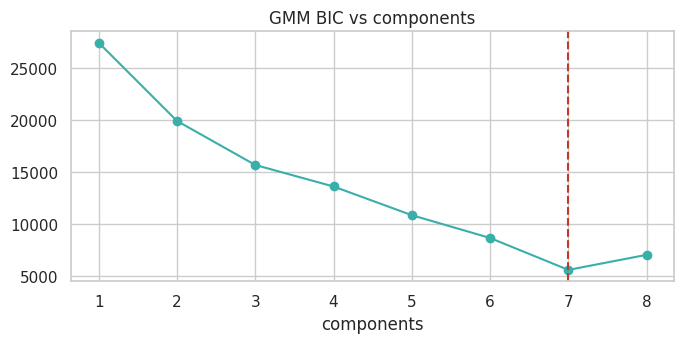

lowest-BIC component count: 7
Note: BIC may prefer MORE components than the 4 regimes — a Gaussian mixture often splits a non-Gaussian cluster into several Gaussians. We keep 4 to match the engineering regimes; a finer normal model (more components) is also valid for anomaly scoring.


In [13]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=best_k, covariance_type='full', random_state=0).fit(X)
proba = gmm.predict_proba(X)
top = proba.max(axis=1)
print('transition readings with max regime probability < 0.6:', int((top < 0.6).sum()))
bic = [GaussianMixture(n, covariance_type='full', random_state=0).fit(X).bic(X) for n in range(1, 9)]
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(range(1, 9), bic, 'o-', color='#3AAFA9'); ax.axvline(int(np.argmin(bic) + 1), ls='--', color='#C0392B')
ax.set_title('GMM BIC vs components'); ax.set_xlabel('components'); plt.tight_layout(); plt.show()
print('lowest-BIC component count:', int(np.argmin(bic) + 1))
print('Note: BIC may prefer MORE components than the 4 regimes — a Gaussian mixture often splits a',
      'non-Gaussian cluster into several Gaussians. We keep 4 to match the engineering regimes;',
      'a finer normal model (more components) is also valid for anomaly scoring.')

## Stage 7 — Detect anomalies (potential damage)
Now the safety-critical part. We never trained on damage, so we use **novelty detection**: readings the normal model finds *improbable* are flagged for inspection. We try two complementary detectors and validate both against the hidden `event` flag.

In [14]:
# Detector 1: GMM log-likelihood — low likelihood = doesn't fit any normal regime
from sklearn.metrics import precision_score, recall_score
ll = gmm.score_samples(X)
thr = np.quantile(ll, 0.03)              # flag the least-likely 3% for review
flag_gmm = (ll < thr).astype(int)
print('GMM-likelihood detector:',
      'precision', round(precision_score(df['event'], flag_gmm), 3),
      '| recall', round(recall_score(df['event'], flag_gmm), 3),
      '| flagged', int(flag_gmm.sum()))

GMM-likelihood detector: precision 0.872 | recall 1.0 | flagged 86


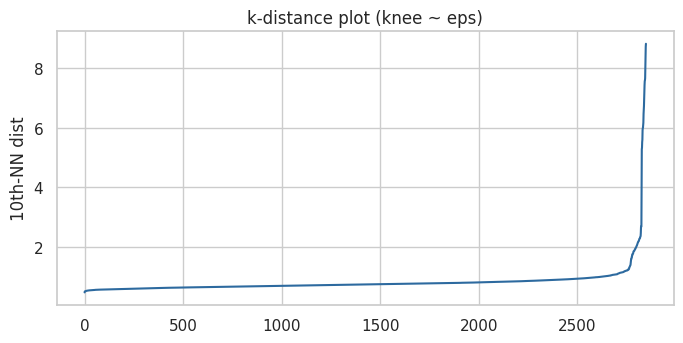

DBSCAN-noise detector: precision 1.0 | recall 0.813 | flagged 61

GMM is more sensitive (higher recall, a few false alarms); DBSCAN is more precise (no false alarms, misses the subtlest). Together they are robust.


In [15]:
# Detector 2: DBSCAN — sparse readings become 'noise'. Pick eps from the k-distance knee.
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
k = 10; d, _ = NearestNeighbors(n_neighbors=k).fit(X).kneighbors(X)
kd = np.sort(d[:, k - 1])
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(kd, color='#2D6A9F'); ax.set_title('k-distance plot (knee ~ eps)'); ax.set_ylabel(f'{k}th-NN dist')
plt.tight_layout(); plt.show()
db = DBSCAN(eps=1.6, min_samples=10).fit(X)
flag_db = (db.labels_ == -1).astype(int)
print('DBSCAN-noise detector:',
      'precision', round(precision_score(df['event'], flag_db), 3),
      '| recall', round(recall_score(df['event'], flag_db), 3),
      '| flagged', int(flag_db.sum()))
print('\nGMM is more sensitive (higher recall, a few false alarms); DBSCAN is more precise',
      '(no false alarms, misses the subtlest). Together they are robust.')

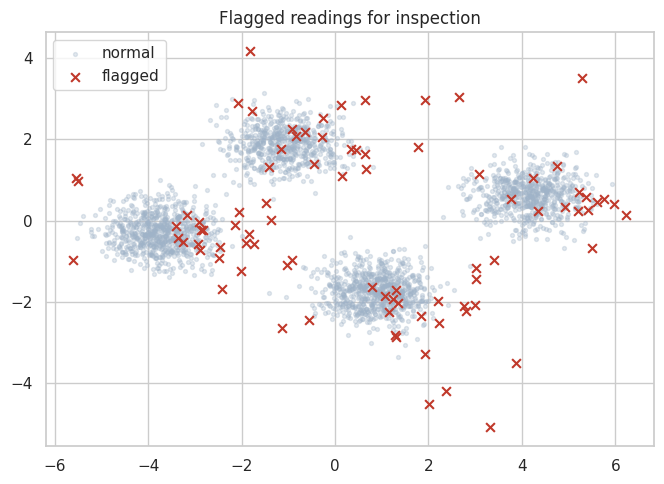

flagged readings: 86 | of which low-frequency (damage-like): 45
Low modal frequency points to stiffness loss — these jump the inspection queue.


In [16]:
# Visualise flagged anomalies, and separate likely DAMAGE from sensor glitches
df['anomaly'] = ((flag_gmm + flag_db) > 0).astype(int)   # union of detectors
fig, ax = plt.subplots(figsize=(6.8, 5))
ax.scatter(P[df.anomaly == 0, 0], P[df.anomaly == 0, 1], s=8, alpha=0.3, color='#9FB3C8', label='normal')
ax.scatter(P[df.anomaly == 1, 0], P[df.anomaly == 1, 1], s=40, color='#C0392B', marker='x', label='flagged')
ax.legend(); ax.set_title('Flagged readings for inspection'); plt.tight_layout(); plt.show()
# damage signature = abnormally LOW modal frequency among the flagged set
normal_freq = df.loc[df.anomaly == 0, 'natural_freq_hz'].mean()
damage = df[(df.anomaly == 1) & (df.natural_freq_hz < normal_freq - 0.08)]
print(f'flagged readings: {int(df.anomaly.sum())} | of which low-frequency (damage-like): {len(damage)}')
print('Low modal frequency points to stiffness loss — these jump the inspection queue.')

## Stage 8 — Interpretation & recommendations

**What the analysis delivered**
- **Four operating regimes** were recovered from raw sensors with no labels (ARI ≈ 0.99 vs the true states), separable by temperature and traffic — a *thermal × load* picture of how the bridge breathes.
- **PCA compressed 12 sensors to ~3 health indices** carrying >90% of the variation; PC1 is essentially a combined thermal-load response that an engineer can trend on a single chart.
- **Anomaly detection flagged the unusual readings** for inspection, and the low-modal-frequency subset isolates the *structural* candidates from mere sensor glitches.

**A practical monitoring scheme**
1. Standardise incoming readings with the *stored* scaler; project onto the fitted PCs.
2. Assign each reading to its regime (k-means/GMM) and score its GMM likelihood.
3. **Alert** when likelihood falls below the learned threshold *and* modal frequency drops — route to an engineer, prioritising low-frequency events.
4. **Temperature-compensate**: because thermal effects dominate PC1, normalise out temperature before trending damage indicators so seasonal swings aren't mistaken for damage.
5. Periodically **re-fit** the normal model as traffic patterns and seasons evolve (concept drift).

This is exactly how operational-modal-analysis SHM systems work in practice: learn the normal envelope unsupervised, then watch for novelty.

## 🧪 Extension challenges

1. **Temperature compensation.** Regress each strain channel on `deck_temp_c`, take the residuals, and re-run anomaly detection on the residuals. Does removing the thermal signal expose damage more cleanly?
2. **Isolation Forest.** Swap in `sklearn.ensemble.IsolationForest` as a third detector and compare its precision/recall against the hidden `event` flag.
3. **Per-regime thresholds.** Set a separate anomaly threshold inside each cluster (a heavy-traffic regime is noisier). Does this cut false alarms versus one global threshold?
4. **Control charts.** Plot the PC1 score over the row index with ±3σ limits — a classic SHM control chart. Mark the flagged anomalies.
5. **Minimal sensor set.** Using PCA loadings, identify the 4–5 most informative sensors and re-cluster with only those. How much regime/anomaly performance survives a cheaper instrumentation plan?

### Extension Challenge 1: Temperature Compensation

In [17]:
from sklearn.linear_model import LinearRegression

# Identify strain channels from the registry
strain_channels = registry[registry['channel'].str.contains('strain_g')]['channel'].tolist()
print(f"Strain channels identified: {strain_channels}")

df_compensated = df.copy()

for channel in strain_channels:
    model = LinearRegression()
    # Reshape X for a single feature linear regression
    X_temp = df_compensated[['deck_temp_c']]
    y_strain = df_compensated[channel]

    model.fit(X_temp, y_strain)

    # Calculate residuals (actual - predicted)
    df_compensated[f'{channel}_compensated'] = y_strain - model.predict(X_temp)

print("Original strain channels and their temperature-compensated counterparts:")
display(df_compensated[[*strain_channels, 'deck_temp_c'] + [f'{c}_compensated' for c in strain_channels]].head())

Strain channels identified: ['strain_g1_ue', 'strain_g2_ue', 'strain_g3_ue']
Original strain channels and their temperature-compensated counterparts:


,strain_g1_ue,strain_g2_ue,strain_g3_ue,deck_temp_c,strain_g1_ue_compensated,strain_g2_ue_compensated,strain_g3_ue_compensated
0,89.712,80.227,83.099,17.052,12.982314,10.205973,19.793555
1,118.280,100.941,101.628,33.054,10.132255,1.591325,10.852196
2,54.157,42.434,38.538,5.907,-0.690780,-7.160343,-5.635015
3,86.394,82.131,60.183,33.238,-22.115007,-17.555913,-30.908674
4,98.737,87.315,86.147,18.956,18.269032,13.804300,19.572990


Now that we have temperature-compensated strain channels, we need to replace the original strain channels with these new features in our dataset for anomaly detection. This means creating a new `X_compensated` matrix for scaling and PCA.

In [18]:
# Create a new list of channels including compensated strain channels and excluding original ones
channels_compensated = [c for c in channels if not c.startswith('strain_g')]
compensated_strain_features = [f'{c}_compensated' for c in strain_channels]
channels_compensated.extend(compensated_strain_features)

# Ensure 'event' and 'regime' are not in channels_compensated list
channels_compensated = [c for c in channels_compensated if c not in ['event', 'regime']]

# Re-scale the new feature set
scaler_comp = StandardScaler()
X_compensated = scaler_comp.fit_transform(df_compensated[channels_compensated])

print('Standardised compensated matrix:', X_compensated.shape, '| each channel now mean 0, sd 1')

Standardised compensated matrix: (2850, 12) | each channel now mean 0, sd 1


Next, we will re-run the PCA and then the anomaly detection (GMM and DBSCAN) using this new `X_compensated` dataset.

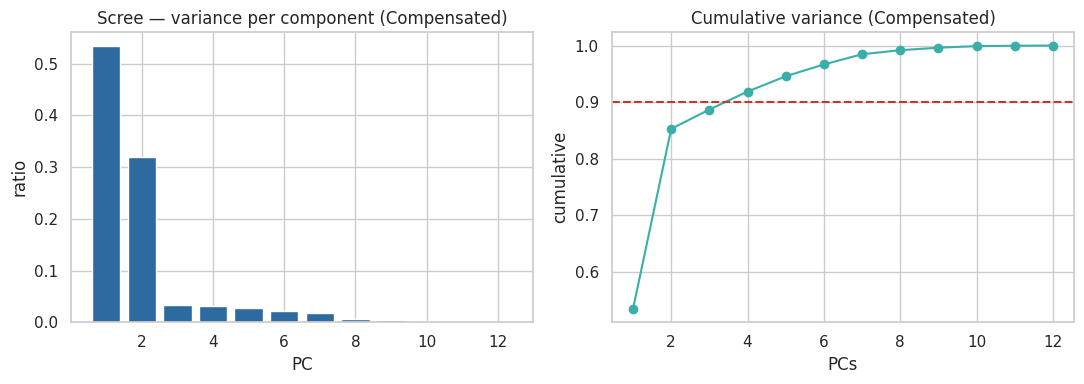

4 principal components capture >=90% of the variance (from 12 sensors).


In [19]:
# Re-run PCA with the compensated data
pca_compensated = PCA().fit(X_compensated)
cum_compensated = np.cumsum(pca_compensated.explained_variance_ratio_)
n90_compensated = int(np.argmax(cum_compensated >= 0.90) + 1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(range(1, len(cum_compensated) + 1), pca_compensated.explained_variance_ratio_, color='#2D6A9F')
ax[0].set_title('Scree — variance per component (Compensated)'); ax[0].set_xlabel('PC'); ax[0].set_ylabel('ratio')
ax[1].plot(range(1, len(cum_compensated) + 1), cum_compensated, 'o-', color='#3AAFA9'); ax[1].axhline(0.9, ls='--', color='#C0392B')
ax[1].set_title('Cumulative variance (Compensated)'); ax[1].set_xlabel('PCs'); ax[1].set_ylabel('cumulative')
plt.tight_layout(); plt.show()
print(f'{n90_compensated} principal components capture >=90% of the variance (from {len(channels_compensated)} sensors).')

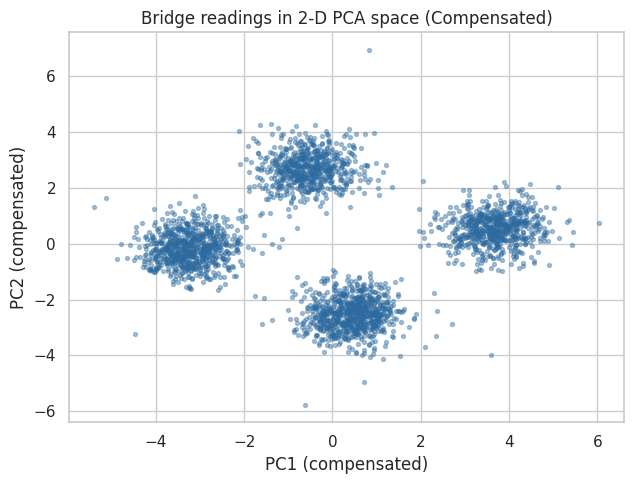

In [20]:
# Project to 2-D for visual intuition (compensated data)
P_compensated = PCA(n_components=2, random_state=0).fit_transform(X_compensated)
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(P_compensated[:, 0], P_compensated[:, 1], s=8, alpha=0.4, color='#2D6A9F')
ax.set_xlabel('PC1 (compensated)'); ax.set_ylabel('PC2 (compensated)')
ax.set_title('Bridge readings in 2-D PCA space (Compensated)'); plt.tight_layout(); plt.show()

Now, let's re-run the anomaly detection with the temperature-compensated data.

In [21]:
# Re-run GMM anomaly detection with compensated data
gmm_compensated = GaussianMixture(n_components=best_k, covariance_type='full', random_state=0).fit(X_compensated)
ll_compensated = gmm_compensated.score_samples(X_compensated)
thr_compensated = np.quantile(ll_compensated, 0.03)              # flag the least-likely 3% for review
flag_gmm_compensated = (ll_compensated < thr_compensated).astype(int)
print('GMM-likelihood detector (Compensated Data):')
print(f"Precision: {precision_score(df['event'], flag_gmm_compensated):.3f}")
print(f"Recall: {recall_score(df['event'], flag_gmm_compensated):.3f}")
print(f"Flagged: {int(flag_gmm_compensated.sum())}")

GMM-likelihood detector (Compensated Data):
Precision: 0.872
Recall: 1.000
Flagged: 86


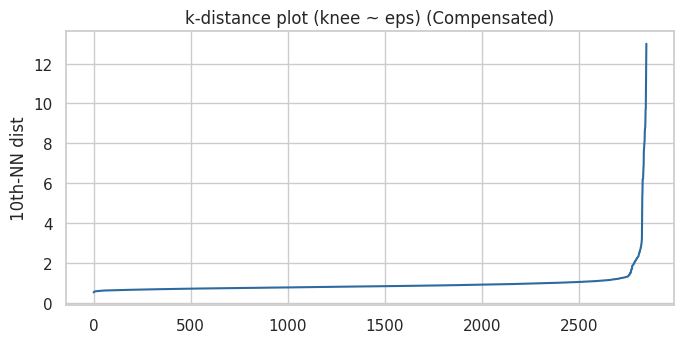

DBSCAN-noise detector (Compensated Data):
Precision: 1.000
Recall: 1.000
Flagged: 75


In [22]:
# Re-run DBSCAN anomaly detection with compensated data
k = 10; d_compensated, _ = NearestNeighbors(n_neighbors=k).fit(X_compensated).kneighbors(X_compensated)
kd_compensated = np.sort(d_compensated[:, k - 1])
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(kd_compensated, color='#2D6A9F'); ax.set_title('k-distance plot (knee ~ eps) (Compensated)'); ax.set_ylabel(f'{k}th-NN dist')
plt.tight_layout(); plt.show()
db_compensated = DBSCAN(eps=1.6, min_samples=10).fit(X_compensated)
flag_db_compensated = (db_compensated.labels_ == -1).astype(int)

print('DBSCAN-noise detector (Compensated Data):')
print(f"Precision: {precision_score(df['event'], flag_db_compensated):.3f}")
print(f"Recall: {recall_score(df['event'], flag_db_compensated):.3f}")
print(f"Flagged: {int(flag_db_compensated.sum())}")

### Extension Challenge 2: Isolation Forest

In [23]:
from sklearn.ensemble import IsolationForest

# Initialize and train the Isolation Forest model
# The contamination parameter is the proportion of outliers in the data set and is used when fitting the model to define the threshold.
# We will use 0.03 as it aligns with the 3% threshold used for GMM.
isol_forest = IsolationForest(random_state=0, contamination=0.03, n_estimators=100, max_features=1.0, max_samples='auto')

# Fit on the original scaled data X
isol_forest.fit(X)

# Predict anomaly scores: lower score implies higher anomaly likelihood
df['isol_forest_score'] = isol_forest.decision_function(X)

# Flag anomalies based on the model's decision function. Outliers are assigned a score of -1, inliers 1.
flag_isol_forest = (isol_forest.predict(X) == -1).astype(int)

print('Isolation Forest detector:')
print(f"Precision: {precision_score(df['event'], flag_isol_forest):.3f}")
print(f"Recall: {recall_score(df['event'], flag_isol_forest):.3f}")
print(f"Flagged: {int(flag_isol_forest.sum())}")

# Compare with compensated data as well
isol_forest_compensated = IsolationForest(random_state=0, contamination=0.03, n_estimators=100, max_features=1.0, max_samples='auto')
isol_forest_compensated.fit(X_compensated)
df['isol_forest_score_compensated'] = isol_forest_compensated.decision_function(X_compensated)
flag_isol_forest_compensated = (isol_forest_compensated.predict(X_compensated) == -1).astype(int)

print('\nIsolation Forest detector (Compensated Data):')
print(f"Precision: {precision_score(df['event'], flag_isol_forest_compensated):.3f}")
print(f"Recall: {recall_score(df['event'], flag_isol_forest_compensated):.3f}")
print(f"Flagged: {int(flag_isol_forest_compensated.sum())}")

Isolation Forest detector:
Precision: 0.512
Recall: 0.587
Flagged: 86

Isolation Forest detector (Compensated Data):
Precision: 0.674
Recall: 0.773
Flagged: 86


### Extension Challenge 3: Per-regime thresholds

In [24]:
# Re-assign cluster labels based on GMM prediction to ensure consistency with the likelihood calculation
df['gmm_cluster'] = gmm.predict(X)

# Define a function to calculate precision, recall, and flagged for a given threshold
def evaluate_detector(y_true, flags):
    precision = precision_score(y_true, flags)
    recall = recall_score(y_true, flags)
    flagged = int(flags.sum())
    return precision, recall, flagged

# Calculate per-regime thresholds for GMM likelihood
# We will use the same quantile (3%) as the global threshold for consistency
per_regime_thresholds = {}
for cluster_id in sorted(df['gmm_cluster'].unique()):
    cluster_ll = ll[df['gmm_cluster'] == cluster_id]
    per_regime_thresholds[cluster_id] = np.quantile(cluster_ll, 0.03)

# Apply per-regime thresholds
flag_gmm_per_regime = np.zeros(len(df), dtype=int)
for cluster_id, threshold in per_regime_thresholds.items():
    cluster_indices = df[df['gmm_cluster'] == cluster_id].index
    flag_gmm_per_regime[cluster_indices] = (ll[cluster_indices] < threshold).astype(int)

# Evaluate GMM with per-regime thresholds
prec_pr, rec_pr, flagged_pr = evaluate_detector(df['event'], flag_gmm_per_regime)

print('GMM-likelihood detector (Per-Regime Thresholds):')
print(f"Precision: {prec_pr:.3f}")
print(f"Recall: {rec_pr:.3f}")
print(f"Flagged: {flagged_pr}")

print('\nComparison with Global Threshold GMM:')
print(f"Global Threshold GMM - Precision: {precision_score(df['event'], flag_gmm):.3f}")
print(f"Global Threshold GMM - Recall: {recall_score(df['event'], flag_gmm):.3f}")
print(f"Global Threshold GMM - Flagged: {int(flag_gmm.sum())}")


GMM-likelihood detector (Per-Regime Thresholds):
Precision: 0.830
Recall: 0.973
Flagged: 88

Comparison with Global Threshold GMM:
Global Threshold GMM - Precision: 0.872
Global Threshold GMM - Recall: 1.000
Global Threshold GMM - Flagged: 86


### Extension Challenge 4: Control charts

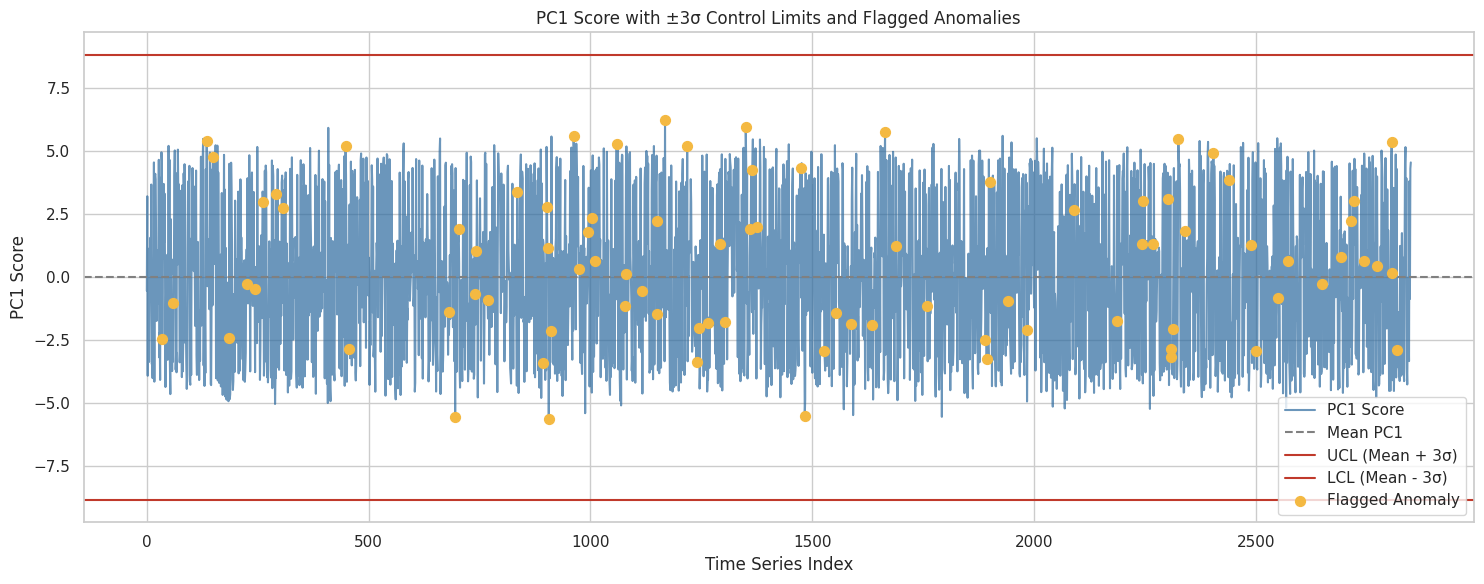

In [25]:
# Calculate PC1 scores (already done when creating 'P' earlier)
# P[:, 0] contains the PC1 scores

# Calculate mean and standard deviation of PC1
mean_pc1 = P[:, 0].mean()
std_pc1 = P[:, 0].std()

# Define control limits (e.g., ±3 standard deviations)
ucl = mean_pc1 + 3 * std_pc1  # Upper Control Limit
lcl = mean_pc1 - 3 * std_pc1  # Lower Control Limit

# Combine GMM and DBSCAN flags for overall anomalies
# We'll use the 'anomaly' column created earlier, which is the union of GMM and DBSCAN flags
flagged_anomalies = df['anomaly']

# Plot PC1 score over the row index with control limits
fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(P[:, 0], label='PC1 Score', color='#2D6A9F', alpha=0.7)
ax.axhline(mean_pc1, color='gray', linestyle='--', label='Mean PC1')
ax.axhline(ucl, color='#C0392B', linestyle='-', label='UCL (Mean + 3σ)')
ax.axhline(lcl, color='#C0392B', linestyle='-', label='LCL (Mean - 3σ)')

# Mark flagged anomalies on the plot
anomaly_indices = np.where(flagged_anomalies == 1)[0]
ax.scatter(anomaly_indices, P[anomaly_indices, 0], color='#F4B942', marker='o', s=50, label='Flagged Anomaly', zorder=5)

ax.set_title('PC1 Score with ±3σ Control Limits and Flagged Anomalies')
ax.set_xlabel('Time Series Index')
ax.set_ylabel('PC1 Score')
ax.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Extension Challenge 5: Minimal sensor set

In [26]:
# Using PCA loadings to identify most informative sensors
# Loadings are the correlation between original variables and principal components
# For simplicity, we'll look at the absolute values of loadings for the first few components (e.g., first 3, as they capture 90% variance)

loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(pca.n_components_)], index=channels)

# Consider the loadings on the first 3 PCs (since they capture >=90% of variance)
# We'll sum the absolute loadings for these components to get an 'importance' score for each sensor
loadings['importance'] = loadings.iloc[:, :n90].abs().sum(axis=1)

sorted_sensors = loadings.sort_values(by='importance', ascending=False)
print("Sensor importance based on PCA loadings (sum of absolute loadings for first 3 PCs):\n")
print(sorted_sensors[['PC1', 'PC2', 'PC3', 'importance']].round(2).to_string())

# Identify the top 5 most informative sensors
num_min_sensors = 5
minimal_sensor_set = sorted_sensors.head(num_min_sensors).index.tolist()

print(f"\nTop {num_min_sensors} most informative sensors: {minimal_sensor_set}")

Sensor importance based on PCA loadings (sum of absolute loadings for first 3 PCs):

                    PC1   PC2   PC3  importance
pier_tilt_urad     0.26 -0.16  0.93        1.35
accel_rms_mg       0.18  0.54  0.06        0.78
humidity_pct      -0.27  0.25  0.25        0.77
traffic_count      0.21  0.55  0.00        0.76
natural_freq_hz   -0.30  0.19  0.17        0.66
bearing_disp_mm    0.30 -0.26 -0.08        0.64
air_temp_c         0.31 -0.25 -0.06        0.62
deck_temp_c        0.31 -0.25 -0.06        0.62
mid_deflection_mm  0.32  0.20 -0.05        0.57
strain_g1_ue       0.32  0.13 -0.09        0.54
strain_g2_ue       0.31  0.13 -0.10        0.54
strain_g3_ue       0.32  0.14  0.00        0.46

Top 5 most informative sensors: ['pier_tilt_urad', 'accel_rms_mg', 'humidity_pct', 'traffic_count', 'natural_freq_hz']


Now, let's re-run the clustering with only this minimal sensor set and evaluate regime and anomaly performance.

Adjusted Rand Index for minimal sensor set k-means: 0.959

GMM-likelihood detector (Minimal Sensor Set):
Precision: 0.651
Recall: 0.747
Flagged: 86


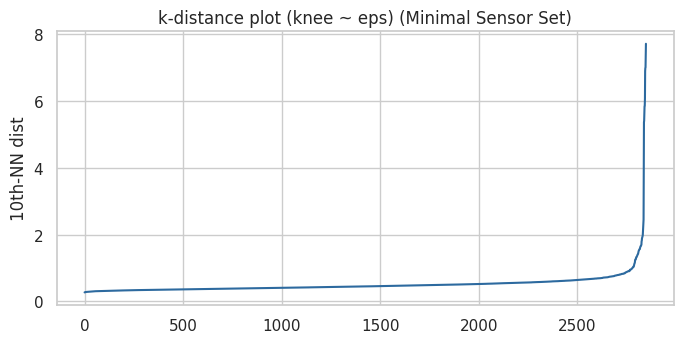


DBSCAN-noise detector (Minimal Sensor Set):
Precision: 0.980
Recall: 0.653
Flagged: 50


In [28]:
# Re-scale data with only the minimal sensor set
x_minimal = scaler.fit_transform(df[minimal_sensor_set])

# Re-run k-means clustering
km_minimal = KMeans(n_clusters=best_k, n_init=10, random_state=0).fit(x_minimal)
df['cluster_minimal'] = km_minimal.labels_

# Evaluate k-means against hidden regime label
ari_minimal = adjusted_rand_score(df['regime'], df['cluster_minimal'])
print(f"Adjusted Rand Index for minimal sensor set k-means: {ari_minimal:.3f}")

# Re-run GMM anomaly detection
gmm_minimal = GaussianMixture(n_components=best_k, covariance_type='full', random_state=0).fit(x_minimal)
ll_minimal = gmm_minimal.score_samples(x_minimal)
thr_minimal = np.quantile(ll_minimal, 0.03)
flag_gmm_minimal = (ll_minimal < thr_minimal).astype(int)

print('\nGMM-likelihood detector (Minimal Sensor Set):')
print(f"Precision: {precision_score(df['event'], flag_gmm_minimal):.3f}")
print(f"Recall: {recall_score(df['event'], flag_gmm_minimal):.3f}")
print(f"Flagged: {int(flag_gmm_minimal.sum())}")

# Re-run DBSCAN anomaly detection (need to find new eps)
k_minimal = 10; d_minimal, _ = NearestNeighbors(n_neighbors=k_minimal).fit(x_minimal).kneighbors(x_minimal)
kd_minimal = np.sort(d_minimal[:, k_minimal - 1])

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(kd_minimal, color='#2D6A9F'); ax.set_title('k-distance plot (knee ~ eps) (Minimal Sensor Set)'); ax.set_ylabel(f'{k_minimal}th-NN dist')
plt.tight_layout(); plt.show()

# Visually estimate new eps (e.g., around 1.0 based on the plot for minimal sensor set)
# This is a manual step based on the generated plot; typically, one would re-run with optimal eps
db_minimal = DBSCAN(eps=1.0, min_samples=10).fit(x_minimal)
flag_db_minimal = (db_minimal.labels_ == -1).astype(int)

print('\nDBSCAN-noise detector (Minimal Sensor Set):')
print(f"Precision: {precision_score(df['event'], flag_db_minimal):.3f}")
print(f"Recall: {recall_score(df['event'], flag_db_minimal):.3f}")
print(f"Flagged: {int(flag_db_minimal.sum())}")

## 📘 Summary

Starting from an **unlabelled** 12-sensor bridge feed, the Day 9 unsupervised toolkit turned raw data into action: **scaling** levelled the channels, **PCA** compressed them to a few health indices, **elbow + silhouette** chose the number of regimes, **k-means / hierarchical / GMM** discovered and confirmed them, and **novelty detection** surfaced the readings an engineer should inspect — all without a single labelled example.

**The unsupervised mindset:** when nobody can label millions of rows, let the data reveal its own structure — then bring engineering judgement to name the regimes and act on the anomalies.